# Third-Party Risk Prediction for Internal Audit

This self-contained notebook creates entirely **hypothetical** vendor data and demonstrates how Internal Audit could rank vendors for deeper review.

## Measurement outcome in plain English
For each vendor, the model estimates the probability that **at least one defined third-party risk event will occur in the next 12 months**. The five modelled outcomes are:

1. overdue periodic review;
2. control deficiency;
3. concentration-risk event;
4. financial distress; and
5. contract non-compliance.

A score of 72% means the model estimates a 72% chance of at least one of these events, based on patterns in the hypothetical training data. It does **not** mean the vendor is 72% non-compliant, that 72% of controls failed, or that an audit finding exists. The score tells Audit where to look first. Evidence and control testing are still required.

## Design

- **Observation unit:** one vendor at one assessment date.
- **Prediction horizon:** the following 12 months.
- **Predictors:** information assumed to be available at the assessment date.
- **Target:** `any_risk_event_12m`, equal to 1 if one or more of the five outcomes occurs, otherwise 0.
- **Candidates:** explainable logistic regression and random forest.
- **Validation:** a held-out test population.
- **Audit output:** ranked vendors, relative priority bands, event-capture analysis and reason summaries.

The simulated relationships are educational assumptions, not estimates of real vendor behaviour.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance

RANDOM_STATE=42
rng=np.random.default_rng(RANDOM_STATE)
pd.set_option('display.max_columns', 200)
print('Libraries loaded.')

Libraries loaded.


## 1. Load extracts from separate source systems

A real organisation would not maintain all predictors in one analytical table. This project therefore starts with eleven hypothetical extracts representing procurement, accounts payable, contract management, third-party governance, issue management, assurance, service management, cyber risk, financial risk, resilience and a future event registry.

Each extract uses a source-specific vendor key and naming convention. The preparation stage renames keys, derives measures from dates, checks uniqueness and joins the sources into one modelling table. This makes the lineage from source extract to model feature explicit.

In [2]:
from pathlib import Path
DATA_DIR=Path('.')
AS_OF_DATE=pd.Timestamp('2025-12-31')
source_files={
 'procurement':'source_01_procurement_vendor_master.csv','spend':'source_02_accounts_payable_spend.csv',
 'contracts':'source_03_contract_lifecycle.csv','governance':'source_04_tprm_governance_workflow.csv',
 'issues':'source_05_g_rc_issue_management.csv','assurance':'source_06_assurance_register.csv',
 'service':'source_07_service_management.csv','cyber':'source_08_cyber_risk_platform.csv',
 'financial':'source_09_financial_risk_and_invoices.csv','resilience':'source_10_resilience_relationship.csv',
 'outcomes':'source_11_future_event_registry.csv'}
raw={name:pd.read_csv(DATA_DIR/file) for name,file in source_files.items()}
for name,frame in raw.items(): print(f'{name:12s}: {len(frame):,} rows, {frame.shape[1]} columns')

procurement : 5,000 rows, 8 columns
spend       : 5,000 rows, 4 columns
contracts   : 5,000 rows, 6 columns
governance  : 5,000 rows, 7 columns
issues      : 5,000 rows, 6 columns
assurance   : 5,000 rows, 5 columns
service     : 5,000 rows, 8 columns
cyber       : 5,000 rows, 6 columns
financial   : 5,000 rows, 7 columns
resilience  : 5,000 rows, 6 columns
outcomes    : 5,000 rows, 6 columns


## 2. Prepare and integrate the source extracts

This stage performs the practical data-engineering work that precedes modelling:

1. standardise the vendor identifier;
2. translate source field names into modelling names;
3. parse contract and governance dates;
4. derive contract age, months to expiry and days overdue as at 31 December 2025;
5. check that each source contains one row per vendor;
6. left join all predictor sources to the procurement master;
7. join separately observed future outcomes; and
8. create the composite target.

The future event registry is used only to create labels for model training and validation. Its five event fields are excluded from predictors.

In [3]:
# Standardise keys and source-specific column names
renames={
 'procurement':{'supplier_id':'vendor_id','country_risk_band':'country_risk','supplier_industry':'industry','business_criticality':'criticality','inherent_tprm_rating':'inherent_risk'},
 'spend':{'vendor_code':'vendor_id','annualised_spend_aud_m':'annual_spend_m','year_on_year_spend_change_pct':'spend_growth_pct','category_spend_share_pct':'spend_concentration_pct'},
 'contracts':{'counterparty_id':'vendor_id','amendment_count_24m':'contract_amendments_24m','obligation_count':'contract_obligation_count','schedule_count':'service_schedule_count'},
 'governance':{'third_party_id':'vendor_id','historic_review_timeliness_rate':'prior_review_on_time_rate','relationship_owner_changes_24m':'ownership_changes_24m','required_training_completion_pct':'mandatory_training_completion_pct'},
 'issues':{'related_party_id':'vendor_id','open_issue_count':'open_issues','overdue_issue_count':'overdue_issues','repeat_issue_count_24m':'repeat_issues_24m','mean_days_to_remediate':'avg_remediation_days','risk_acceptance_count_24m':'risk_acceptances_24m'},
 'assurance':{'assessed_entity_id':'vendor_id','assurance_exception_count':'assurance_exceptions','high_severity_finding_count':'high_severity_assurance_findings','months_since_independent_assurance':'independent_assurance_age_months'},
 'service':{'service_provider_id':'vendor_id','sla_breach_count_12m':'sla_breaches_12m','incident_count_12m':'operational_incidents_12m','critical_incident_count_12m':'critical_incidents_12m','mean_time_to_resolve_hours':'mean_incident_resolution_hours','executive_escalation_count_12m':'executive_escalations_12m','complaint_count_12m':'complaints_12m'},
 'cyber':{'external_org_id':'vendor_id','open_critical_vulnerability_count':'critical_vulnerabilities','average_critical_patch_age_days':'avg_critical_patch_days','security_incident_count_24m':'security_incidents_24m','penetration_test_high_finding_count':'penetration_test_high_findings','third_party_cyber_rating':'external_cyber_score'},
 'financial':{'legal_entity_vendor_id':'vendor_id','latest_revenue_change_pct':'revenue_growth_pct','external_credit_score':'credit_score','supplier_days_payable_outstanding':'days_payable_outstanding','invoice_dispute_count_12m':'invoice_disputes_12m'},
 'resilience':{'vendor_reference':'vendor_id','business_service_dependency_pct':'service_dependency_pct','viable_alternative_provider_count':'alternate_provider_count','single_region_delivery_pct':'geographic_concentration_pct','declared_subcontractor_count':'subcontractor_count','relationship_manager_change_count_24m':'relationship_manager_changes_24m'},
 'outcomes':{'vendor_key':'vendor_id'}}
clean={name:frame.rename(columns=renames[name]).copy() for name,frame in raw.items()}

# Derive model-ready measures from operational dates
c=clean['contracts']
c['contract_start_date']=pd.to_datetime(c['contract_start_date'],dayfirst=True)
c['contract_end_date']=pd.to_datetime(c['contract_end_date'],dayfirst=True)
c['contract_age_months']=((AS_OF_DATE-c['contract_start_date']).dt.days/30.4375).round().astype(int)
c['contract_months_to_expiry']=((c['contract_end_date']-AS_OF_DATE).dt.days/30.4375).round().astype(int)
c.drop(columns=['contract_start_date','contract_end_date'],inplace=True)
g=clean['governance']
for date_col,out_col in [('next_review_due_date','review_days_overdue'),('risk_assessment_due_date','risk_assessment_days_overdue'),('attestation_due_date','attestation_days_overdue')]:
    due=pd.to_datetime(g[date_col])
    g[out_col]=np.maximum((AS_OF_DATE-due).dt.days,0)
g.drop(columns=['next_review_due_date','risk_assessment_due_date','attestation_due_date'],inplace=True)

# Data quality controls before joins
for name,frame in clean.items():
    if frame['vendor_id'].isna().any(): raise ValueError(f'Missing vendor key in {name}')
    if frame['vendor_id'].duplicated().any(): raise ValueError(f'Duplicate vendor key in {name}')

# Procurement is the population anchor. Predictor sources are left joined.
predictor_order=['spend','contracts','governance','issues','assurance','service','cyber','financial','resilience']
vendors=clean['procurement'].copy()
for name in predictor_order:
    vendors=vendors.merge(clean[name],on='vendor_id',how='left',validate='one_to_one')

# Future outcomes are kept separate until label construction.
outcomes=['overdue_review_12m','control_deficiency_12m','concentration_event_12m','financial_distress_12m','contract_non_compliance_12m']
vendors=vendors.merge(clean['outcomes'],on='vendor_id',how='left',validate='one_to_one')
vendors['any_risk_event_12m']=(vendors[outcomes].sum(axis=1)>0).astype(int)
v=vendors
print(f'Integrated modelling table: {len(vendors):,} vendors, {vendors.shape[1]} columns')
print('Missing predictor values:',int(vendors.drop(columns=outcomes+['any_risk_event_12m']).isna().sum().sum()))
summary=pd.DataFrame({'outcome':outcomes+['any_risk_event_12m'],'count':[int(v[c].sum()) for c in outcomes+['any_risk_event_12m']],'rate':[v[c].mean() for c in outcomes+['any_risk_event_12m']]})
display(summary.style.format({'rate':'{:.1%}'}))
vendors.head()

Integrated modelling table: 5,000 vendors, 60 columns
Missing predictor values: 0


,outcome,count,rate
0,overdue_review_12m,733,14.7%
1,control_deficiency_12m,655,13.1%
2,concentration_event_12m,499,10.0%
3,financial_distress_12m,614,12.3%
4,contract_non_compliance_12m,493,9.9%
5,any_risk_event_12m,2341,46.8%


,vendor_id,country_risk,industry,criticality,inherent_risk,outsourcing_category,vendor_age_years,years_with_company,annual_spend_m,spend_growth_pct,spend_concentration_pct,contract_amendments_24m,contract_obligation_count,service_schedule_count,contract_age_months,contract_months_to_expiry,prior_review_on_time_rate,ownership_changes_24m,mandatory_training_completion_pct,review_days_overdue,risk_assessment_days_overdue,attestation_days_overdue,open_issues,overdue_issues,repeat_issues_24m,avg_remediation_days,risk_acceptances_24m,assurance_exceptions,high_severity_assurance_findings,control_maturity_score,independent_assurance_age_months,sla_breaches_12m,availability_pct,operational_incidents_12m,critical_incidents_12m,mean_incident_resolution_hours,executive_escalations_12m,complaints_12m,critical_vulnerabilities,avg_critical_patch_days,security_incidents_24m,penetration_test_high_findings,external_cyber_score,revenue_growth_pct,debt_to_ebitda,current_ratio,credit_score,days_payable_outstanding,invoice_disputes_12m,service_dependency_pct,alternate_provider_count,geographic_concentration_pct,subcontractor_count,relationship_manager_changes_24m,overdue_review_12m,control_deficiency_12m,concentration_event_12m,financial_distress_12m,contract_non_compliance_12m,any_risk_event_12m
0,VEN-00001,Medium,Professional Services,Medium,Medium,Outsourcing,14.708394,0.618431,4.926534,-10.007022,35.865541,5,25,6,73,2,0.867755,0,76.285581,0,0,0,1,0,0,81.808188,0,1,0,3.996449,2.652359,3,99.097549,1,1,25.969639,0,1,1,62.416386,0,0,717.769035,-15.851604,2.431958,1.541724,780.782900,39.296616,0,40.123393,2,70.203565,2,1,0,0,0,0,1,1
1,VEN-00002,Low,Payments,High,Low,Material outsourcing,16.980882,4.311321,1.337156,-20.498013,20.248325,1,15,4,28,26,0.904570,3,90.487502,0,0,0,3,0,0,117.764818,0,2,0,2.975488,9.349259,0,99.048847,1,0,8.765869,1,0,1,5.667447,0,0,695.573929,15.762484,1.246456,1.577796,579.261149,32.043756,0,11.053736,5,18.846639,3,0,0,0,0,0,0,0
2,VEN-00003,Medium,Facilities,Low,Low,Non-outsourcing,10.444307,5.027722,1.568973,-15.679791,11.477777,3,26,4,43,16,0.657687,1,84.239297,0,178,0,7,3,1,106.182799,0,2,2,2.440288,15.173942,4,99.672129,2,0,13.805572,0,1,1,20.930275,0,0,606.380260,11.202932,2.174265,0.977615,622.551071,55.286362,1,22.761816,2,19.019977,3,2,0,1,0,0,0,1
3,VEN-00004,Medium,Facilities,Medium,High,Outsourcing,13.997358,8.264499,4.922637,19.585158,28.034402,0,27,7,87,5,0.697831,1,76.230852,25,0,125,3,2,1,31.108692,0,0,0,4.012165,16.705065,4,98.245306,0,0,18.058563,0,2,2,51.404468,3,1,693.497042,-6.466631,4.290587,1.435718,681.872815,14.614865,1,58.113774,3,44.566488,4,3,0,0,0,0,1,1
4,VEN-00005,Low,Payments,Medium,Medium,Non-outsourcing,3.128515,3.128515,6.082752,11.487311,23.804605,0,26,5,116,22,0.905961,1,97.399270,0,0,0,3,1,0,96.872298,0,1,0,1.470891,7.197975,3,100.000000,1,0,14.419147,0,2,0,10.512658,1,0,664.974419,35.771528,1.123723,0.559433,561.766334,53.137342,2,13.468749,4,44.394731,3,0,0,0,0,0,0,0


## 3. Split, preprocess and train

The held-out test set is not used to fit the models. Numeric values are median-imputed and standardised. Categories are imputed and one-hot encoded. Two candidates are fitted so the demonstration does not assume one algorithm is always best.

In [4]:
target='any_risk_event_12m'
features=[c for c in v.columns if c not in ['vendor_id',target]+outcomes]
X,y=v[features],v[target]
cat_cols=X.select_dtypes(include='object').columns.tolist(); num_cols=X.select_dtypes(exclude='object').columns.tolist()
Xtr,Xte,ytr,yte,idtr,idte=train_test_split(X,y,v.vendor_id,test_size=.25,stratify=y,random_state=RANDOM_STATE)
prep=ColumnTransformer([('num',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),num_cols),('cat',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('encode',OneHotEncoder(handle_unknown='ignore'))]),cat_cols)])
models={
 'Logistic regression':Pipeline([('prepare',prep),('model',LogisticRegression(max_iter=2000,class_weight='balanced',random_state=RANDOM_STATE))]),
 'Random forest':Pipeline([('prepare',prep),('model',RandomForestClassifier(n_estimators=300,min_samples_leaf=8,class_weight='balanced_subsample',random_state=RANDOM_STATE,n_jobs=-1))])}
for name,m in models.items(): m.fit(Xtr,ytr); print(name,'fitted')
print(f'Train: {len(Xtr):,}; test: {len(Xte):,}; test event rate: {yte.mean():.1%}')

Logistic regression fitted


Random forest fitted
Train: 3,750; test: 1,250; test event rate: 46.8%


## 4. Evaluate in plain language

- **ROC AUC:** ranking quality. It is the chance that an event vendor receives a higher score than a non-event vendor. 0.5 is random ranking; 1.0 is perfect.
- **Average precision:** summarises how effectively the model finds event vendors, especially when events are uncommon.
- **Precision:** among vendors classified positive, the share that had an event.
- **Recall:** among vendors that had an event, the share identified.
- **F1:** balance of precision and recall.
- **Accuracy:** overall share classified correctly. It may mislead where one outcome dominates.

A 50% classification threshold is shown only for demonstration. Audit should set thresholds using review capacity and the cost of missed risk.

In [5]:
rows=[]
for name,m in models.items():
 p=m.predict_proba(Xte)[:,1]; pred=(p>=.5).astype(int)
 rows.append({'model':name,'roc_auc':roc_auc_score(yte,p),'average_precision':average_precision_score(yte,p),'accuracy':accuracy_score(yte,pred),'precision':precision_score(yte,pred,zero_division=0),'recall':recall_score(yte,pred,zero_division=0),'f1':f1_score(yte,pred,zero_division=0)})
results=pd.DataFrame(rows)
display(results.style.format({c:'{:.3f}' for c in results.columns if c!='model'}))
best_name=results.sort_values('roc_auc',ascending=False).iloc[0].model
best=models[best_name]; prob=best.predict_proba(Xte)[:,1]; pred=(prob>=.5).astype(int)
print('Selected demonstration model:',best_name)
display(pd.DataFrame(confusion_matrix(yte,pred),index=['Actual no event','Actual event'],columns=['Predicted no event','Predicted event']))

,model,roc_auc,average_precision,accuracy,precision,recall,f1
0,Logistic regression,0.697,0.688,0.642,0.615,0.626,0.620
1,Random forest,0.696,0.672,0.640,0.622,0.590,0.605


Selected demonstration model: Logistic regression


,Predicted no event,Predicted event
Actual no event,436,229
Actual event,219,366


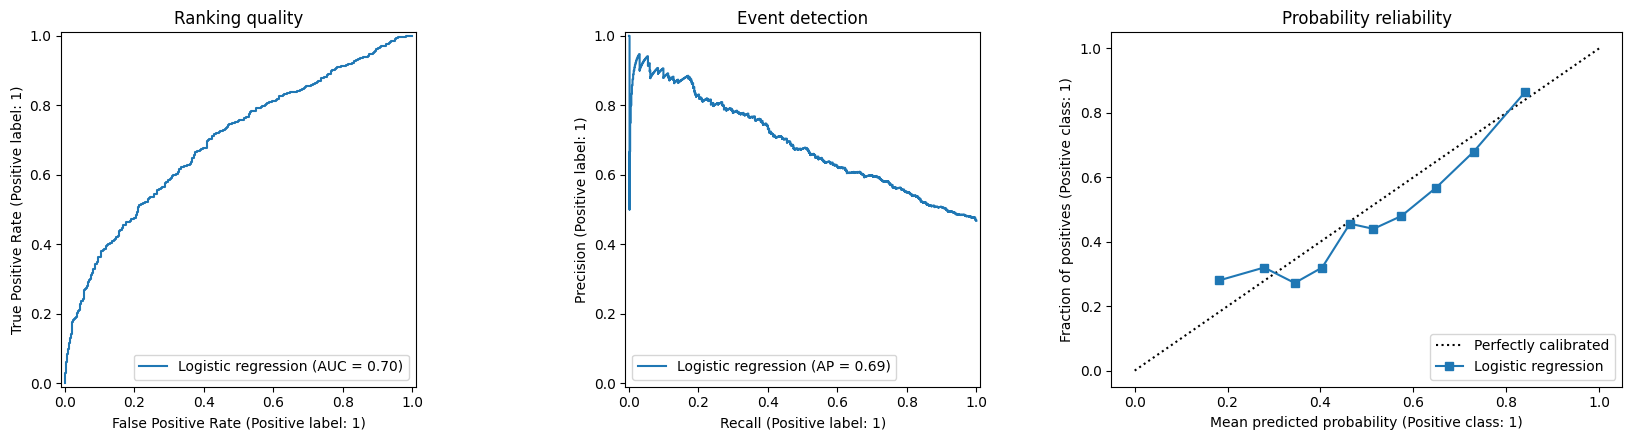

In [6]:
fig,ax=plt.subplots(1,3,figsize=(17,4.5))
RocCurveDisplay.from_predictions(yte,prob,ax=ax[0],name=best_name); ax[0].set_title('Ranking quality')
PrecisionRecallDisplay.from_predictions(yte,prob,ax=ax[1],name=best_name); ax[1].set_title('Event detection')
CalibrationDisplay.from_predictions(yte,prob,n_bins=10,strategy='quantile',ax=ax[2],name=best_name); ax[2].set_title('Probability reliability')
plt.tight_layout(); plt.show()

## 5. Convert probability into audit priority

The notebook uses relative workload bands: Critical is the top 5% of scores, High is the next 15%, Medium is the next 30%, and Low is the remaining 50%. These are not formal management risk ratings. Production thresholds should align with audit capacity and the approved framework.

In [7]:
scored=Xte.copy(); scored.insert(0,'vendor_id',idte.values); scored['actual_any_risk_event_12m']=yte.values; scored['predicted_risk_probability']=prob
q95,q80,q50=scored.predicted_risk_probability.quantile([.95,.80,.50])
scored['audit_priority']=pd.cut(scored.predicted_risk_probability,[-np.inf,q50,q80,q95,np.inf],labels=['Low','Medium','High','Critical'])
bands=scored.groupby('audit_priority',observed=False).agg(vendors=('vendor_id','count'),average_score=('predicted_risk_probability','mean'),observed_event_rate=('actual_any_risk_event_12m','mean'),events=('actual_any_risk_event_12m','sum')).reset_index()
display(bands.style.format({'average_score':'{:.1%}','observed_event_rate':'{:.1%}'}))
ranked=scored.sort_values('predicted_risk_probability',ascending=False).reset_index(drop=True)
total=ranked.actual_any_risk_event_12m.sum(); capture=[]
for share in [.05,.10,.20,.30]:
 n=int(np.ceil(len(ranked)*share)); found=int(ranked.head(n).actual_any_risk_event_12m.sum())
 capture.append({'top_share_tested':share,'vendors_tested':n,'events_found':found,'share_of_all_events_found':found/total})
display(pd.DataFrame(capture).style.format({'top_share_tested':'{:.0%}','share_of_all_events_found':'{:.1%}'}))

,audit_priority,vendors,average_score,observed_event_rate,events
0,Low,625,33.4%,33.0%,206
1,Medium,375,57.9%,49.6%,186
2,High,187,75.3%,72.7%,136
3,Critical,63,88.0%,90.5%,57


,top_share_tested,vendors_tested,events_found,share_of_all_events_found
0,5%,63,57,9.7%
1,10%,125,108,18.5%
2,20%,250,193,33.0%
3,30%,375,264,45.1%


## 6. Explain model reliance and individual records

Permutation importance asks how much ranking performance falls when one predictor is shuffled. It indicates model reliance, not causation. The vendor reason summary uses transparent review triggers. It is contextual and not an exact mathematical decomposition of the model score.

,predictor,importance,uncertainty
18,review_days_overdue,0.027095,0.003897
43,debt_to_ebitda,0.020265,0.003750
15,prior_review_on_time_rate,0.019202,0.003275
48,service_dependency_pct,0.013646,0.004527
27,high_severity_assurance_findings,0.013513,0.003220
28,control_maturity_score,0.013413,0.001811
19,risk_assessment_days_overdue,0.010313,0.003430
45,credit_score,0.009235,0.002610
22,overdue_issues,0.009209,0.002210
16,ownership_changes_24m,0.008710,0.004179


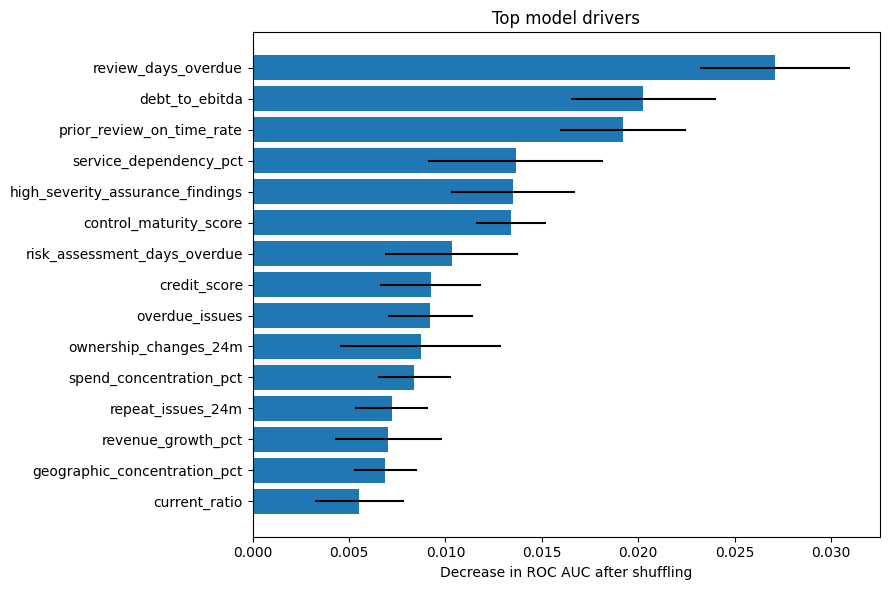

,vendor_id,predicted_risk_probability,audit_priority,actual_any_risk_event_12m,review_reason_summary
0,VEN-01920,94.7%,Critical,1,3 issues are overdue; 2 repeat issues exist; elevated leverage of 4.4; no alternate provider recorded; 2 executive escalations
1,VEN-01959,94.5%,Critical,0,periodic review is 149 days overdue; 4 issues are overdue; 3 executive escalations; contract expiry date has passed
2,VEN-01884,94.4%,Critical,1,risk assessment is 153 days overdue; elevated leverage of 11.1
3,VEN-04049,94.1%,Critical,1,risk assessment is 64 days overdue; 2 issues are overdue; 1 high-severity assurance finding(s); 3 critical vulnerabilities; elevated leverage of 5.0
4,VEN-01160,93.8%,Critical,1,periodic review is 197 days overdue; risk assessment is 94 days overdue; 5 service-level breaches; elevated leverage of 4.9
5,VEN-01381,93.8%,Critical,1,periodic review is 208 days overdue; elevated leverage of 7.4
6,VEN-04503,93.3%,Critical,1,1 high-severity assurance finding(s); low credit score of 522; elevated leverage of 6.2; no alternate provider recorded
7,VEN-04700,93.3%,Critical,1,risk assessment is 142 days overdue; no alternate provider recorded; 2 executive escalations; contract expiry date has passed
8,VEN-02151,93.0%,Critical,1,periodic review is 171 days overdue; risk assessment is 178 days overdue; 3 repeat issues exist; low credit score of 523
9,VEN-00571,93.0%,Critical,1,periodic review is 199 days overdue; 3 critical vulnerabilities; no alternate provider recorded


In [8]:
pi=permutation_importance(best,Xte,yte,n_repeats=4,scoring='roc_auc',random_state=RANDOM_STATE,n_jobs=-1)
imp=pd.DataFrame({'predictor':Xte.columns,'importance':pi.importances_mean,'uncertainty':pi.importances_std}).sort_values('importance',ascending=False)
display(imp.head(15))
p=imp.head(15).sort_values('importance'); plt.figure(figsize=(9,6)); plt.barh(p.predictor,p.importance,xerr=p.uncertainty); plt.xlabel('Decrease in ROC AUC after shuffling'); plt.title('Top model drivers'); plt.tight_layout(); plt.show()

def reasons(r):
 checks=[(r.review_days_overdue>60,f'periodic review is {r.review_days_overdue:.0f} days overdue'),(r.risk_assessment_days_overdue>45,f'risk assessment is {r.risk_assessment_days_overdue:.0f} days overdue'),(r.overdue_issues>=2,f'{r.overdue_issues:.0f} issues are overdue'),(r.repeat_issues_24m>=2,f'{r.repeat_issues_24m:.0f} repeat issues exist'),(r.high_severity_assurance_findings>=1,f'{r.high_severity_assurance_findings:.0f} high-severity assurance finding(s)'),(r.sla_breaches_12m>=5,f'{r.sla_breaches_12m:.0f} service-level breaches'),(r.critical_vulnerabilities>=3,f'{r.critical_vulnerabilities:.0f} critical vulnerabilities'),(r.credit_score<560,f'low credit score of {r.credit_score:.0f}'),(r.debt_to_ebitda>4,f'elevated leverage of {r.debt_to_ebitda:.1f}'),(r.service_dependency_pct>70,f'high service dependency of {r.service_dependency_pct:.0f}%'),(r.alternate_provider_count==0,'no alternate provider recorded'),(r.executive_escalations_12m>=2,f'{r.executive_escalations_12m:.0f} executive escalations'),(r.contract_months_to_expiry<0,'contract expiry date has passed')]
 hit=[t for c,t in checks if c]; return '; '.join(hit[:5]) if hit else 'combined pattern of predictors; no simple trigger exceeded'
ranked['review_reason_summary']=ranked.apply(reasons,axis=1)
display(ranked[['vendor_id','predicted_risk_probability','audit_priority','actual_any_risk_event_12m','review_reason_summary']].head(20).style.format({'predicted_risk_probability':'{:.1%}'}))

## 7. Export the integrated analytical table and model outputs

The outputs are synthetic and must not be represented as genuine vendor data.

In [9]:
v.to_csv('hypothetical_vendor_risk_data.csv',index=False)
ranked.to_csv('vendor_risk_scores_test_set.csv',index=False)
results.to_csv('model_performance.csv',index=False)
print('CSV files exported.')

CSV files exported.


## Audit interpretation and limitations

### Appropriate use

- Prioritise which vendors receive early or deeper review.
- Identify contextual indicators for preliminary enquiry.
- Measure the share of observed events captured at different audit capacities.
- Combine targeted selection with representative sampling and mandatory judgemental selections.

### Inappropriate conclusions

- A high score does not establish a control failure or contract breach.
- A low score does not establish that a vendor is safe.
- Predictor importance does not prove causation.
- Synthetic performance does not demonstrate expected real-world performance.
- The score should not autonomously change vendor ratings, terminate contracts or determine accountability.

### Minimum production safeguards

1. Agree outcome definitions, materiality and prediction dates.
2. Confirm every predictor existed before the outcome period.
3. Reconcile source populations and document lineage.
4. Assess missing data, duplicates, stale fields and inconsistent identifiers.
5. Use time-based back-testing, not only a random split.
6. Compare against existing ratings and simple rules.
7. Select thresholds based on capacity and false-negative cost.
8. Test calibration and performance across legitimate vendor segments.
9. Review privacy, sensitive attributes and proxy risks.
10. Define human review, challenge, override and escalation rules.
11. Retain code, versions, input snapshots, thresholds and outputs as evidence.
12. Monitor drift and realised outcomes, and revalidate before continued use.